In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv('D:/Important Files/Machine Learning/Datasets/data_science_job.csv')
df.sample(5)

,enrollee_id,city,city_development_index,gender,relevent_experience,enrolled_university,education_level,major_discipline,experience,company_size,company_type,training_hours,target
16008,23993,city_21,0.624,Male,No relevent experience,no_enrollment,Graduate,STEM,17.0,NaN,NaN,50.0,1.0
16859,25799,city_160,0.920,Male,No relevent experience,Full time course,Graduate,STEM,1.0,NaN,NaN,112.0,0.0
17978,7727,city_75,0.939,Male,Has relevent experience,no_enrollment,Masters,STEM,9.0,100-500,Pvt Ltd,94.0,0.0
11779,30629,city_101,0.558,Male,Has relevent experience,no_enrollment,Graduate,STEM,8.0,10/49,Early Stage Startup,21.0,1.0
16044,8946,city_76,0.698,Male,No relevent experience,no_enrollment,Graduate,STEM,4.0,50-99,Pvt Ltd,16.0,1.0


In [54]:
df.isnull().sum()

enrollee_id                  0
city                         0
city_development_index     479
gender                    4508
relevent_experience          0
enrolled_university        386
education_level            460
major_discipline          2813
experience                  65
company_size              5938
company_type              6140
training_hours             766
target                       0
dtype: int64

In [55]:
df.isnull().mean() * 100

enrollee_id                0.000000
city                       0.000000
city_development_index     2.500261
gender                    23.530640
relevent_experience        0.000000
enrolled_university        2.014824
education_level            2.401086
major_discipline          14.683161
experience                 0.339284
company_size              30.994885
company_type              32.049274
training_hours             3.998330
target                     0.000000
dtype: float64

In [56]:
df.shape

(19158, 13)

##### While performing CCA, our first consideration is that we apply CCA only on those columns in which the total number of missing data is less than 5%

In [57]:
cols = [col for col in df.columns if df[col].isnull().mean() < 0.05 and df[col].isnull().mean() > 0]
cols

['city_development_index',
 'enrolled_university',
 'education_level',
 'experience',
 'training_hours']

In [58]:
df[cols].sample(5)

,city_development_index,enrolled_university,education_level,experience,training_hours
14685,0.910,no_enrollment,Graduate,8.0,33.0
6778,0.926,Full time course,Graduate,2.0,NaN
18469,0.939,Full time course,Graduate,20.0,6.0
15421,0.754,Part time course,Graduate,6.0,105.0
17506,0.624,no_enrollment,Graduate,7.0,50.0


In [59]:
len(df[cols].dropna()) / len(df)

0.8968577095730244

In [60]:
new_df = df[cols].dropna()
df.shape, new_df.shape

((19158, 13), (17182, 5))

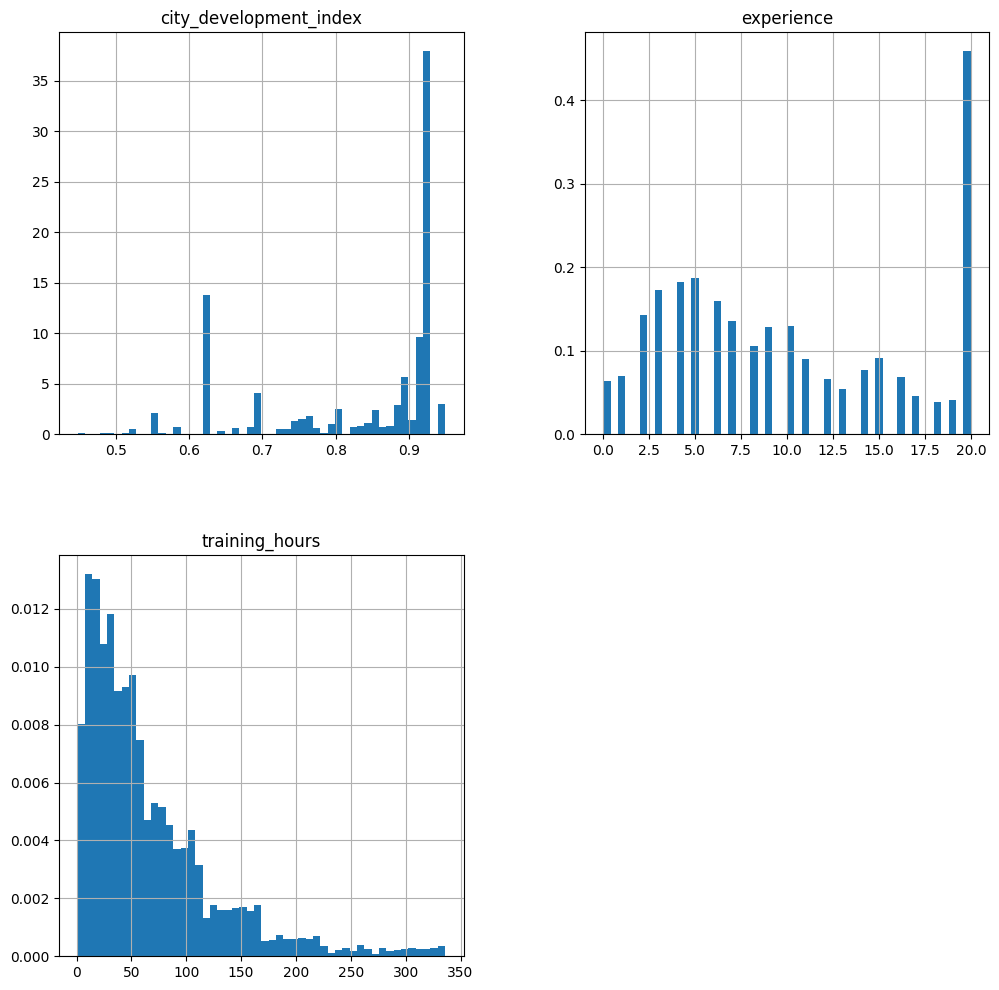

In [61]:
new_df.hist(bins=50, density=True, figsize=(12, 12))

plt.show()

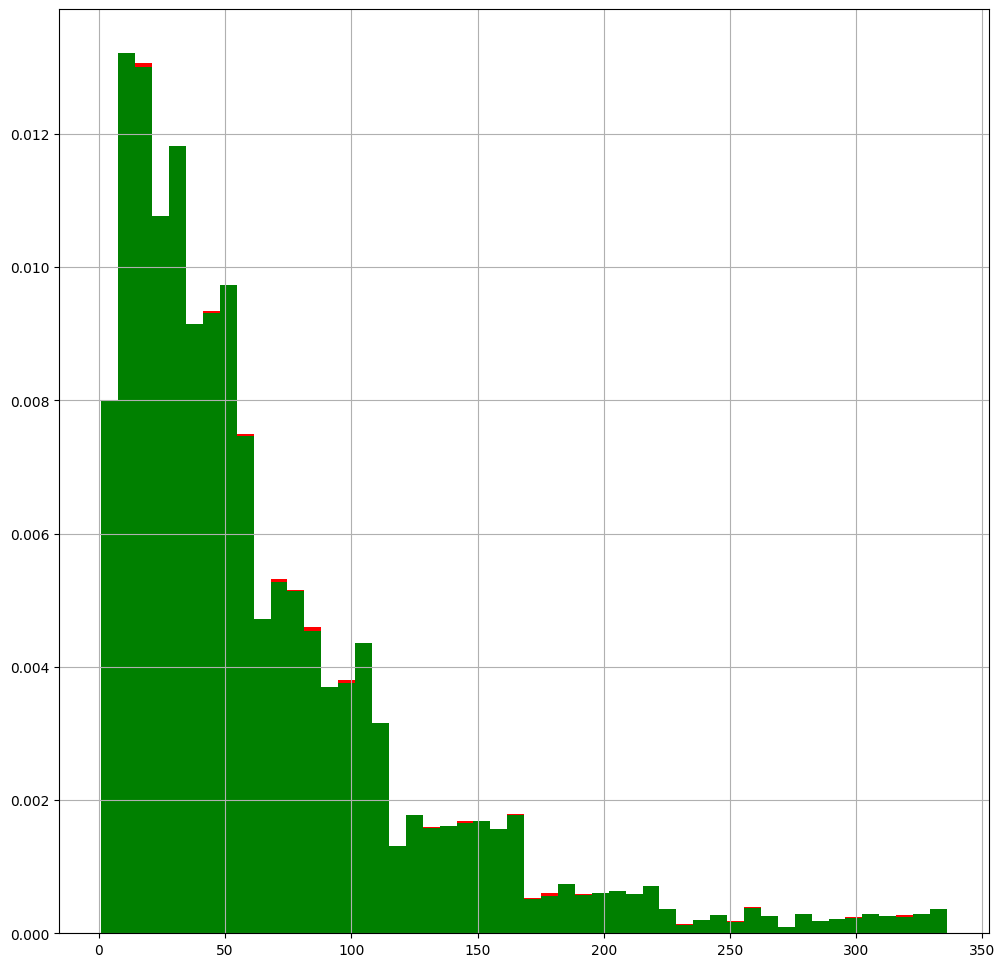

In [62]:

df['training_hours'].hist(bins=50, density=True, color='red', figsize=(12, 12))
new_df['training_hours'].hist(bins=50, density=True, color='green', figsize=(12, 12))
plt.show()

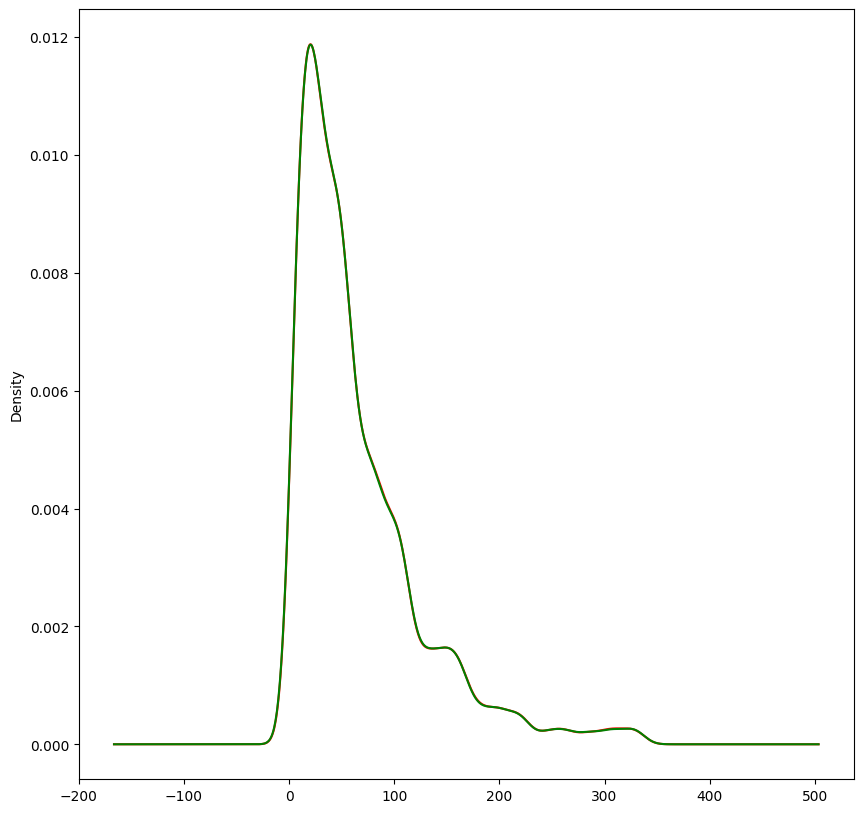

In [63]:
df['training_hours'].plot.density(color='red',figsize=(10, 10))
new_df['training_hours'].plot.density(color='green',figsize=(10, 10))
plt.show()

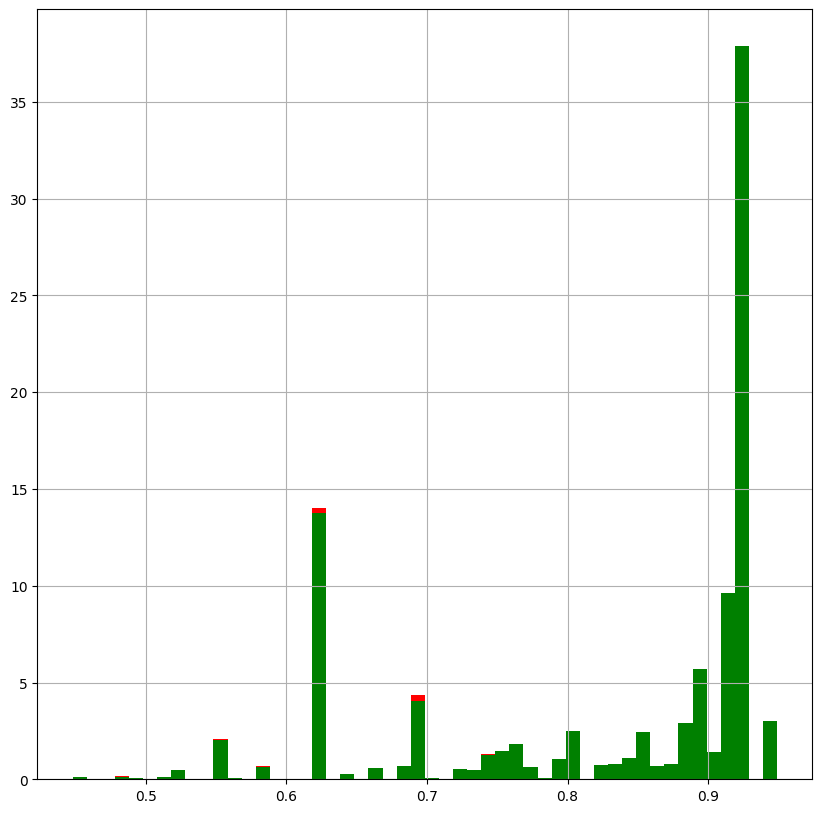

In [64]:
df['city_development_index'].hist(bins=50, density=True, color='red', figsize=(10, 10))
new_df['city_development_index'].hist(bins=50, density=True, color='green', figsize=(10, 10))
plt.show()

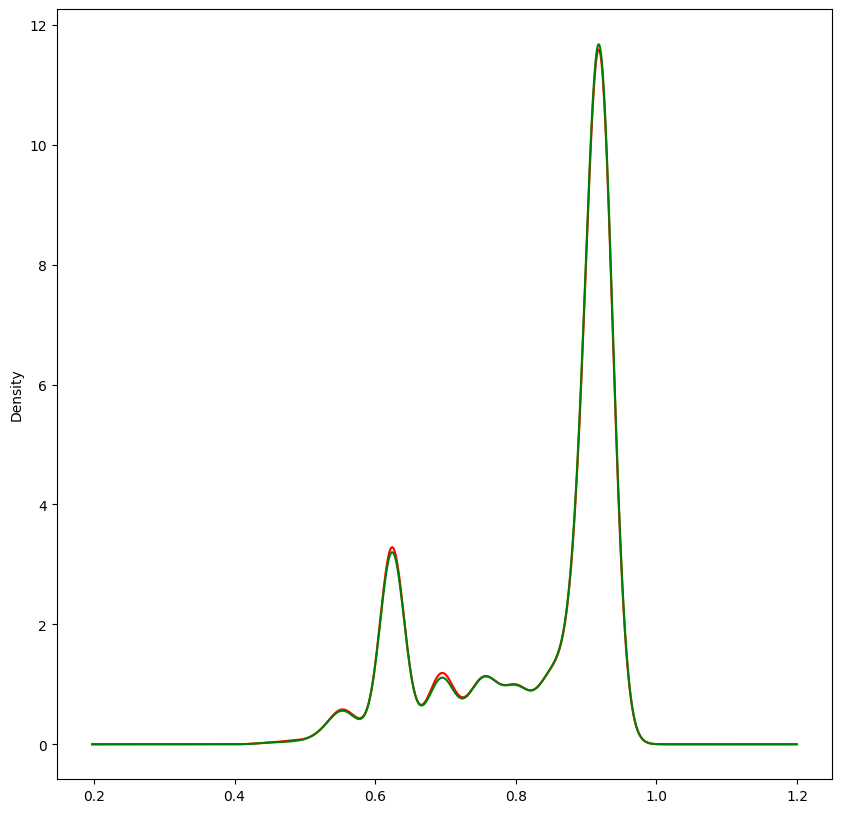

In [65]:
df['city_development_index'].plot.density(color='red',figsize=(10, 10))
new_df['city_development_index'].plot.density(color='green',figsize=(10, 10))
plt.show()

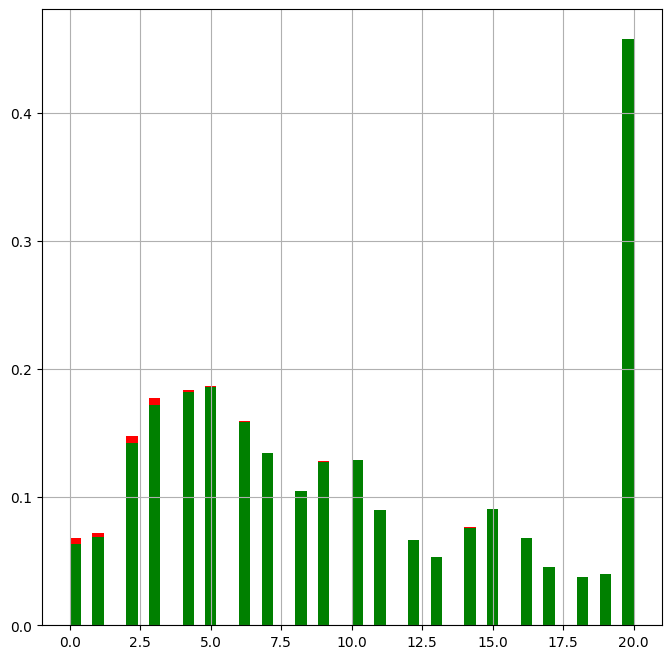

In [66]:
df['experience'].hist(bins=50, density=True, color='red', figsize=(8, 8))
new_df['experience'].hist(bins=50, density=True, color='green', figsize=(8, 8))
plt.show()

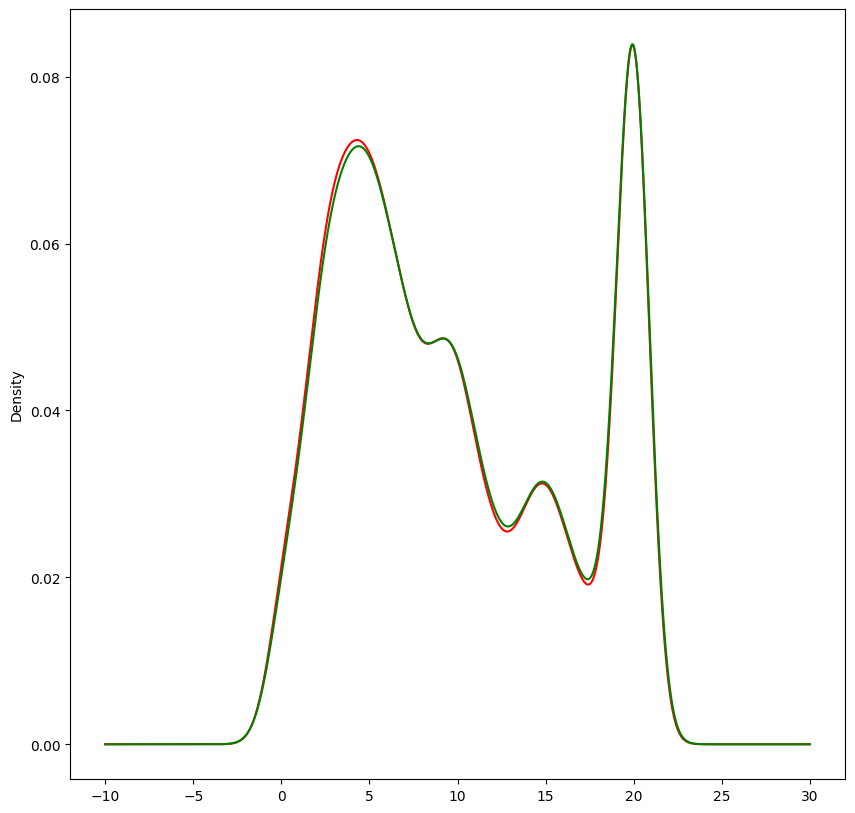

In [67]:
df['experience'].plot.density(color='red',figsize=(10, 10))
new_df['experience'].plot.density(color='green',figsize=(10, 10))
plt.show()

In [68]:
temp = pd.concat([
            df['enrolled_university'].value_counts() / len(df),
            new_df['enrolled_university'].value_counts() / len(df)
],axis=1)
temp.columns = ['original','cca']
temp

,original,cca
enrolled_university,,
no_enrollment,0.721213,0.659359
Full time course,0.196106,0.180029
Part time course,0.062533,0.057469


In [69]:
temp = pd.concat([
            df['education_level'].value_counts() / len(df),
            new_df['education_level'].value_counts() / len(df)
],axis=1)
temp.columns = ['original','cca']
temp

,original,cca
education_level,,
Graduate,0.605387,0.555904
Masters,0.227633,0.209938
High School,0.105282,0.096304
Phd,0.021610,0.019835
Primary School,0.016077,0.014876
